##############################################################################
##############################################################################
#                              SERIES TEMPORAIS                              #
##############################################################################
##############################################################################


## O que é uma Série Temporal?

Uma **série temporal** é uma sequência de observações coletadas ao longo do tempo, onde a ordem das observações é importante. Diferente de dados transversais (cross-section), em séries temporais cada ponto está associado a um instante específico.

**Exemplos comuns:**
- Cotação de ações
- Temperatura diária
- Vendas mensais de uma loja
- Tráfego de usuários em um site

O principal objetivo da análise de séries temporais é **entender o comportamento passado** e **prever valores futuros**.

### Componentes de uma Série Temporal

1. **Tendência (Trend):** movimento de longo prazo, indicando crescimento ou declínio.
2. **Sazonalidade (Seasonality):** padrões repetitivos em intervalos fixos (ex.: picos de vendas no Natal).
3. **Ciclo (Cycle):** oscilações de período não fixo (ex.: ciclos econômicos).
4. **Ruído Aleatório (Noise/Residual):** variações inexplicáveis, sem padrão definido.

### Tipos de Dados

- **Discretos:** contagens (ex.: número de passageiros por mês).
- **Contínuos:** grandezas medidas (ex.: temperatura, pressão arterial).

### Importância da Ordem Temporal

Em séries temporais, a ordem importa porque há **dependência temporal**: o valor atual tende a estar relacionado aos valores passados (autocorrelação).


In [1]:
# Importação das bibliotecas necessárias para análise de séries temporais
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats


from Series_Temporais import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error


###############################################################################
###############################################################################
### Metodos SIMPLES de Previsao de Series Temporais
###############################################################################
###############################################################################


## Métodos Simples de Previsão

Métodos simples são aqueles que não exigem modelagem estatística complexa. Eles servem como **benchmark** para avaliar modelos mais sofisticados. Se um modelo complexo não superar um método simples, ele provavelmente não é viável.

Os métodos simples mais conhecidos são:

- **Naive:** a previsão para o futuro é simplesmente o último valor observado.
- **Média:** a previsão é a média de todos os valores históricos.
- **Drift:** uma variação do Naive que considera a tendência histórica (inclinação média).
- **Naive Sazonal:** usa o valor da mesma posição no ciclo anterior (ex.: janeiro de 2024 para prever janeiro de 2025).

Esses métodos são rápidos, intuitivos e excelentes para **validação base**.


In [2]:
# Série temporal de exemplo utilizada nos métodos simples de previsão

serie = np.array([3, 5, 9, 20, 12, 17, 22, 23, 51, 41, 56, 75, 60, 75, 88])


In [3]:
# Função para realizar previsão naive e calcular intervalos de confiança ajustados

def naive_forecast(time_series, h=3, confidence_level=0.95):
    # A ultima observacao da serie
    last_observation = time_series[-1]
    
    # Previsoes naive para h passos a  frente
    forecasts = np.array([last_observation] * h)
    
    # Calculando os erros de previsao
    errors = time_series[1:] - time_series[:-1] 
    erro2=errors*errors
    std_error =np.sqrt(erro2.mean())  # Desvio dos erros
    
    # Valor cri­tico da distribuicao normal para o ni­vel de confianca desejado
    z_value = stats.norm.ppf((1 + confidence_level) / 2)
    
    # Calculando os intervalos de confianca com ajuste para h passos a  frente
    confidence_intervals = [
        (forecast - z_value * std_error * np.sqrt(step+1), 
         forecast + z_value * std_error * np.sqrt(step+1))
        for step, forecast in enumerate(forecasts)
    ]
    
    # Criando um DataFrame para armazenar previsoes e intervalos de confianca
    forecast_df = pd.DataFrame({
        "Previsao": forecasts,
        "IC Inferior": [ci[0] for ci in confidence_intervals],
        "IC Superior": [ci[1] for ci in confidence_intervals]
    }, index=[f'T+{i+1}' for i in range(h)])
    
    return forecast_df, confidence_intervals


In [4]:
# Função para plotar a série temporal com previsões e intervalos de confiança

def plot_naive_forecast(time_series, forecast_df):
    n = len(time_series)
    h = len(forecast_df)
    
    plt.figure(figsize=(10, 6))
    
    # Plotando os valores reais da serie temporal
    plt.plot(range(n), time_series, label='Serie Temporal', color='blue')
    
    # Plotando os valores previstos
    plt.plot(range(n-1, n+h), np.concatenate(([time_series[-1]], 
                                              forecast_df['Previsao'])), 
             label='Previsao (Naive)', linestyle='--', marker='o', color='orange')

    # Plotando os limites inferior e superior dos intervalos de confianca
    plt.plot(range(n, n+h), forecast_df['IC Inferior'], 
             label='IC Inferior (95%)', linestyle='--', color='red')
    plt.plot(range(n, n+h), forecast_df['IC Superior'],
             label='IC Superior (95%)', linestyle='--', color='green')

    # Adicionando ro­tulos e legendas
    plt.title('Previsao Naive com Intervalos de Confianca (95%)')
    plt.xlabel('Tempo')
    plt.ylabel('Valor')
    plt.legend()
    plt.grid(True)
    
    # Exibindo o grafico
    plt.show()


     Previsao  IC Inferior  IC Superior
T+1        88    62.633795   113.366205
T+2        88    52.126769   123.873231
T+3        88    44.064444   131.935556


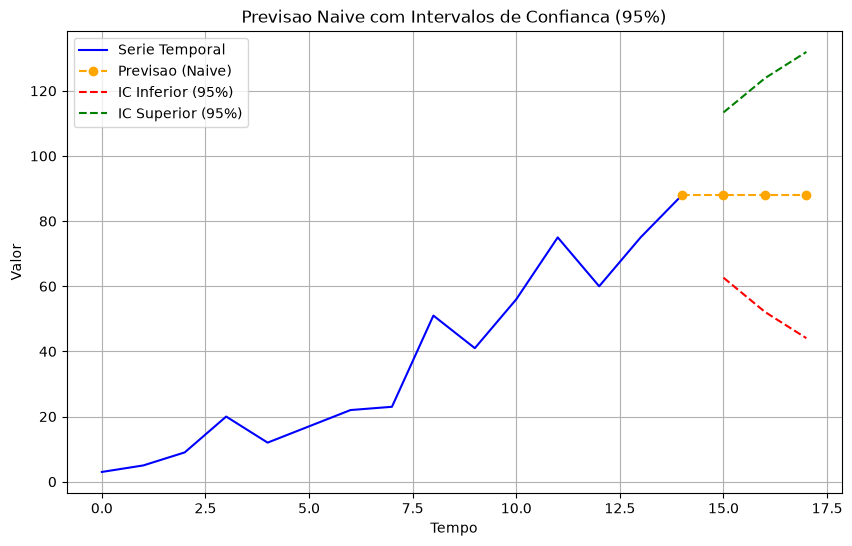

In [5]:
# Aplicando a previsão naive com intervalos de confiança ajustados

naiveforecast_df, confidence_intervals = naive_forecast(serie, h=3)

# Mostrando o DataFrame com previsoes
print(naiveforecast_df)

# Plotando os resultados com previsoes e intervalos de confianca como linhas
plot_naive_forecast(serie, naiveforecast_df)


###----------------------Estatísticas de Erro ----------------


## Estatísticas de Erro

Para avaliar a qualidade de uma previsão, utilizamos métricas que comparam os valores **reais** ($y_t$) com os valores **previstos** ($\hat{y}_t$).

### Métricas principais

**ME (Mean Error / Erro Médio)**
- Fórmula: $ME = \frac{1}{n} \sum (y_t - \hat{y}_t)$
- Mede o viés médios dos erros.
- Problema: erros positivos e negativos podem se anular, mascarando a performance.

**MAE (Mean Absolute Error / Erro Absoluto Médio)**
- Fórmula: $MAE = \frac{1}{n} \sum |y_t - \hat{y}_t|$
- Mede o erro médio absoluto, sem cancelamento de sinais.
- Interpretação: média de desvio entre real e previsto (na mesma unidade da variável).

**RMSE (Root Mean Squared Error)**
- Fórmula: $RMSE = \sqrt{\frac{1}{n} \sum (y_t - \hat{y}_t)^2}$
- Penaliza mais erros grandes (quadrado).
- Interpretação: raiz quadrada da média dos erros ao quadrado.

**MPE (Mean Percentage Error)**
- Fórmula: $MPE = \frac{100}{n} \sum \frac{y_t - \hat{y}_t}{y_t}$
- Mede o viés percentual.
- Problema: pode ser distorcido por valores reais muito pequenos (divisão por número próximo de zero).

**MAPE (Mean Absolute Percentage Error)**
- Fórmula: $MAPE = \frac{100}{n} \sum \left| \frac{y_t - \hat{y}_t}{y_t} \right|$
- Mede o erro percentual médio absoluto.
- Interpretação: percentual médio de desvio entre previsão e realidade.
- Limitação: não funciona bem quando $y_t \approx 0$.

**Theil's U (Coeficiente de Desigualdade de Theil)**
- Fórmula: $U = \frac{\sqrt{\frac{1}{n} \sum (y_t - \hat{y}_t)^2}}{\sqrt{\frac{1}{n} \sum y_t^2} + \sqrt{\frac{1}{n} \sum \hat{y}_t^2}}$
- Mede a acurácia relativa da previsão.
- **U < 1:** previsão é melhor que um modelo ingênuo (random walk).
- **U = 1:** desempenho equivalente ao modelo ingênuo.
- **U > 1:** previsão pior que o modelo ingênuo.

### Quando usar cada métrica?

- Use **MAE** quando quiser uma interpretação direta na unidade da variável.
- Use **RMSE** quando erros grandes forem mais graves.
- Use **MAPE** para relatórios executivos e comparação relativa, evitando valores próximos de zero.
- Use **Theil's U** para comparar contra um modelo baseline.


In [6]:
# Separação de valores reais e previstos para cálculo de erros

reais = serie[1:]  # Valores reais a partir do segundo ponto
previstos = serie[:-1]  # Previsão Naive (valor anterior)


In [7]:
# Cálculos de Erro

erro = reais - previstos
merror = np.mean(erro)
mae = mean_absolute_error(reais, previstos)
rmse = root_mean_squared_error(reais, previstos)
mpe = np.mean((reais - previstos) / reais) * 100
mape = mean_absolute_percentage_error(reais, previstos) * 100


In [8]:
# Coeficiente de desigualdade de Theil (U)
# Mede a acurácia relativa: U < 1 indica que a previsão é melhor que o caminho aleatório

theil = np.sqrt(np.mean(erro**2)) / (np.sqrt(np.mean(reais**2)) + np.sqrt(np.mean(previstos**2)))


In [9]:
# Exibição dos Resultados

print("\nIndicadores de Acuracia")
print(f'ME - Mean Error: {merror:.2f}')
print(f'MAE - Mean Absolute Error: {mae:.2f}')
print(f'RMSE - Raiz Quadrada do Erro Medio: {rmse:.2f}')
print(f'MPE - Mean Percentage Error: {mpe:.2f}%')
print(f'MAPE - Mean Absolute Percentage Error: {mape:.2f}%')
print(f'THEIL_U - Theils Inequality Coefficient: {theil:.4f}')



Indicadores de Acuracia
ME - Mean Error: 6.07
MAE - Mean Absolute Error: 10.79
RMSE - Raiz Quadrada do Erro Medio: 12.94
MPE - Mean Percentage Error: 15.83%
MAPE - Mean Absolute Percentage Error: 32.41%
THEIL_U - Theils Inequality Coefficient: 0.1448


##############################################################################################################################################################
### Metodo de previsao pela MEDIA 
##############################################################################################################################################################


## Método da Média

A previsão pela **média histórica** é o método mais simples: todos os valores futuros previstos são iguais à média aritmética da série.

### Fórmula

$\hat{y}_{t+h} = \bar{y} = \frac{1}{n} \sum_{t=1}^{n} y_t$

### Características

- **Vantagem:** simples, rápida e não assume tendência ou sazonalidade.
- **Desvantagem:** lisa a série, ignorando padrões temporais; se houver tendência, erra sistematicamente.
- **Intervalo de Confiança:** baseado na distribuição t-student, considerando o desvio padrão dos resíduos.

### Aplicabilidade

Útil para séries estacionárias (média e variância constantes) e como baseline. Em séries com tendência ou sazonalidade fortes, tende a ser superestimada ou subestimada.


In [10]:
# Função para realizar previsão pela média e calcular intervalos de confiança

def forecast_with_mean(time_series, steps_ahead, confidence=0.95):
    # Calcular a media da serie
    mean_series = np.mean(time_series)
    
    # Calcular os erros (resi­duos) da previsao pela media
    errors = time_series - mean_series
    
    # Calcular o desvio padrao dos erros
    std_errors = np.std(errors, ddof=1)
    
    # Prever com base na media
    forecast = [mean_series] * steps_ahead

    # Calcular intervalo de confianca usando o desvio padrao dos erros
    n = len(time_series)
    alpha = 1 - confidence
    t_value = stats.t.ppf(1 - alpha/2, df=n-1)  
    margin_of_error = t_value * std_errors*np.sqrt(1+1/len(time_series))
    
    # Inferior e superior
    lower_bound = [mean_series - margin_of_error] * steps_ahead
    upper_bound = [mean_series + margin_of_error] * steps_ahead

    return forecast, lower_bound, upper_bound


In [11]:
# Função para plotar a série original e a previsão pela média

def plot_forecast_with_mean(time_series, forecast, lower_bound,
                                             upper_bound, steps_ahead):
    # Plotar a serie original
    plt.plot(range(len(time_series)), time_series, label="Serie Original", 
             marker='o')
    
    # Criar eixo de tempo para previsao
    forecast_range = range(len(time_series), len(time_series) + steps_ahead)
    
    # Plotar a previsao
    plt.plot(forecast_range, forecast, label="Previsao", marker='o', 
             linestyle='--')
    
    # Plotar intervalo de confianca
    plt.fill_between(forecast_range, lower_bound, upper_bound, color='gray',
                     alpha=0.05, label='Intervalo de Confianca')
    
    # Detalhes do grafico
    plt.xlabel("Tempo")
    plt.ylabel("Valores")
    plt.legend()
    plt.title("Serie Original e Previsao com Intervalo de Confianca pela media")
    plt.show()


Resultados da Previsão
------------------------------
Previsão:                           37.13
Limite inferior do intervalo de confiança: -25.77
Limite superior do intervalo de confiança: 100.04
------------------------------


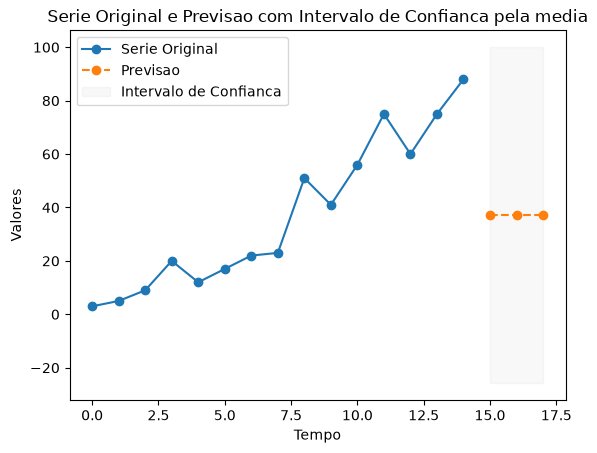

In [12]:
# Definir numero de passos a  frente

h = 3

# Gerar previsao e intervalos de confianca
forecast_mean, lower_bound, upper_bound = forecast_with_mean(serie, h)

forecast_mean

# Exibir resultados

print("Resultados da Previsão")
print("-" * 30)
# Usamos [0] para pegar o primeiro valor da lista de previsões
print(f"Previsão:                           {forecast_mean[0]:.2f}")
print(f"Limite inferior do intervalo de confiança: {lower_bound[0]:.2f}")
print(f"Limite superior do intervalo de confiança: {upper_bound[0]:.2f}")
print("-" * 30)


# Chamar a funcao de plotagem
plot_forecast_with_mean(serie, forecast_mean, lower_bound, upper_bound, h)


##############################################################################################################################################################
### Metodo de previsao com DRIFT
##############################################################################################################################################################


## Método de Drift

O método **Drift** é uma extensão do Naive que captura a **tendência** linear observada na série histórica, assumindo que a inclinação média do passado se mantém no futuro.

### Fórmula

$\hat{y}_{t+h} = y_t + h \cdot \frac{y_t - y_1}{t - 1}$

Onde:
- $y_t$: último valor observado
- $y_1$: primeiro valor observado
- $h$: horizonte de previsão

### Características

- **Vantagem:** captura tendência de forma simples; melhor que o Naive em séries crescentes/decrescentes.
- **Desvantagem:** assume tendência linear constante; sensível a valores extremos iniciais e finais.
- **Intervalo de Confiança:** amplia-se com o horizonte $h$, refletindo crescente incerteza.

### Comparação com o Naive

- **Naive:** $\hat{y}_{t+h} = y_t$ (linha horizontal)
- **Drift:** $\hat{y}_{t+h} = y_t + h \cdot drift$ (reta inclinada)


In [13]:
# Função para calcular a previsão pelo modelo de Drift

def drift_forecast(time_series, steps_ahead, confidence=0.95):
    n = len(time_series)
    
    # Previsao pelo modelo de drift
    drift = (time_series[-1] - time_series[0]) / (n - 1)
    forecast = [time_series[-1] + (i + 1) * drift for i in range(steps_ahead)]
    
    # Calculo dos erros 
    predicted_values = []
    for i in range(1, n):
        predicted_values.append(time_series[i-1] + drift)
    
    # Calcular os erros como a diferenca entre os valores reais e os previstos
    errors = time_series[1:] - np.array(predicted_values)
    erro2=errors*errors
   
    # Calcular o desvio dos erros
    std_errors = np.sqrt(erro2.mean())
  
    # variavel auxiliar para o intervalo de confianca
    calc = len(errors)
   
    # Calcular intervalo de confianca usando o desvio padrao dos erros
    z_value = stats.norm.ppf((1 + confidence) / 2)
   
    # Limites inferior e superior
    lower_bound = [forecast[i] -
                   z_value * std_errors * np.sqrt((i+1)*(1+(i+1)/(calc -1)))
                   for i in range(steps_ahead)]
    upper_bound = [forecast[i] +
                   z_value * std_errors * np.sqrt((i+1)*(1+(i+1)/(calc -1))) 
                   for i in range(steps_ahead)]
         
    return forecast, lower_bound, upper_bound


In [14]:
# Função para plotar a série original e a previsão pelo modelo de Drift

def plot_forecast_with_drift(time_series, forecast, lower_bound,
                                             upper_bound, steps_ahead):
    # Plotar a serie original
    plt.plot(range(len(time_series)), time_series, label="Serie Original",
             marker='o')
    
    # Criar eixo de tempo para previsao
    forecast_range = range(len(time_series), len(time_series) + steps_ahead)
    
    # Plotar a previsao
    plt.plot(forecast_range, forecast, label="Previsao (Drift)", marker='o', 
             linestyle='--')
    
    # Plotar intervalo de confianca
    plt.fill_between(forecast_range, lower_bound, upper_bound, color='gray', 
                     alpha=0.05, label='Intervalo de Confianca')
    
    # Detalhes do grafico
    plt.xlabel("Tempo")
    plt.ylabel("Valores")
    plt.legend()
    plt.title("Serie Original e Previsao pelo Modelo de Drift com Intervalo de Confianca")
    plt.show()


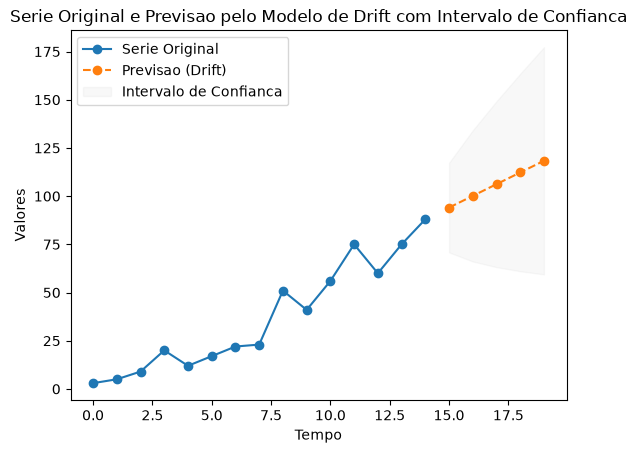

In [15]:
# Definir numero de passos a  frente

h = 5

# Gerar previsao e intervalos de confianca pelo modelo de Drift
forecast_drift, lower_bound, upper_bound = drift_forecast(serie, h)

forecast_drift
lower_bound
upper_bound

# Chamar a funcao de plotagem
plot_forecast_with_drift(serie, forecast_drift, lower_bound, upper_bound, h)


##############################################################################################################################################################
### Metodo de previsao com NAIVE SAZONAL
##############################################################################################################################################################


## Método Naive Sazonal

O **Naive Sazonal** considera que o valor futuro será igual ao valor observado **no mesmo ponto do ciclo anterior**. É especialmente útil quando há padrões repetitivos bem definidos.

### Fórmula

$\hat{y}_{t+h} = y_{t - m + h}$

Onde:
- $m$: período sazonal (ex.: 12 meses, 7 dias, 4 trimestres)
- $h$: horizonte dentro do ciclo ( $h \in {1, 2, ..., m}$)

### Exemplos de Sazonalidade

- $m = 12$: dados mensais com sazonalidade anual (ex.: vendas de Natal).
- $m = 7$: dados diários com sazonalidade semanal (ex.: tráfego de site).
- $m = 4$: dados trimestrais com sazonalidade anual.

### Características

- **Vantagem:** captura padrões sazonais de forma direta e robusta.
- **Desvantagem:** não captura tendência de longo prazo; assume que o padrão sazonal se repete.
- **Intervalo de Confiança:** considera o desvio padrão dos resíduos sazonais, expandindo-se ao longo do horizonte.

### Quando usar?

- Quando a série apresenta **sazonalidade dominante**.
- Como baseline para modelos mais complexos como **SARIMA**, **Prophet** ou **Exponential Smoothing**.


In [16]:
# Método de previsão com Naive Sazonal

# Funcao para rodar o modelo Naive Sazonal com intervalos de confianca
def seasonal_naive_forecast(time_series, season_length, steps_ahead, confidence=0.95):
    """
    time_series: Série temporal
    season_length: Período sazonal (ex: 12 meses para sazonalidade mensal)
    steps_ahead: O número de períodos à frente para previsão
    confidence: Nível de confiança (95% por padrão)
    """
    # Prever o valor com base na sazonalidade anterior
    forecast = [time_series.iloc[-season_length + i] for i in range(steps_ahead)]
    
    # Previsão dos valores dentro da série histórica para obter resíduos
    predicted_values = [time_series.iloc[i - season_length] for i in range(season_length, len(time_series))]
  
    # Calcular os erros residuais
    residuals = time_series.iloc[season_length:] - np.array(predicted_values)
    
    # Calcular o quadrado dos erros (resíduos)
    errors2 = residuals ** 2
    
    # Calcular o desvio padrão dos erros
    std_residuals = np.sqrt(errors2.mean())
  
    # Calcular o valor crítico z para o intervalo de confiança
    z_value = stats.norm.ppf((1 + confidence) / 2)
    
    # Calcular a margem de erro
    margin_of_error = z_value * std_residuals
    
    # Definir limites inferiores e superiores dos intervalos de confiança
    lower_bound = [forecast[i] - margin_of_error * np.sqrt((i // season_length) + 1) for i in range(steps_ahead)]
    upper_bound = [forecast[i] + margin_of_error * np.sqrt((i // season_length) + 1) for i in range(steps_ahead)]
    
    return forecast, lower_bound, upper_bound


In [17]:
# Funcao para plotar a serie original, previsao e intervalos de confianca

def plot_seasonal_naive_forecast(time_series, forecast, lower_bound,
                                  upper_bound, steps_ahead):
    # Plotar a serie original
    plt.plot(range(len(time_series)), time_series, label="Serie Original",
             marker='o')
    
    # Criar eixo de tempo para previsao
    forecast_range = range(len(time_series), len(time_series) + steps_ahead)
    
    # Plotar a previsao
    plt.plot(forecast_range, forecast, label="Previsao (Naive Sazonal)", 
             marker='o', linestyle='--')
    
    # Plotar intervalo de confianca
    plt.fill_between(forecast_range, lower_bound, upper_bound, color='gray',
                     alpha=0.2, label='Intervalo de Confianca')
    
    # Detalhes do grafico
    plt.xlabel("Tempo")
    plt.ylabel("Valores")
    plt.legend()
    plt.title("Serie Original e Previsao pelo Modelo Naive Sazonal com Intervalo de Confianca")
    plt.show()


In [18]:
# Importando a base de dados
# pip install --upgrade openpyxl

airp = pd.read_excel("airpassengers.xlsx")

# Lendo a base de dados
print(airp.head())


         mes  passengers
0 2007-01-01         112
1 2007-02-01         118
2 2007-03-01         132
3 2007-04-01         129
4 2007-05-01         121


In [19]:
# Definindo a serie temporal com frequencia mensal

airpas = pd.Series(airp.iloc[:, 1].values, 
                    index=pd.date_range(start='2007-01-01', periods=len(airp), 
                                        freq='ME'))


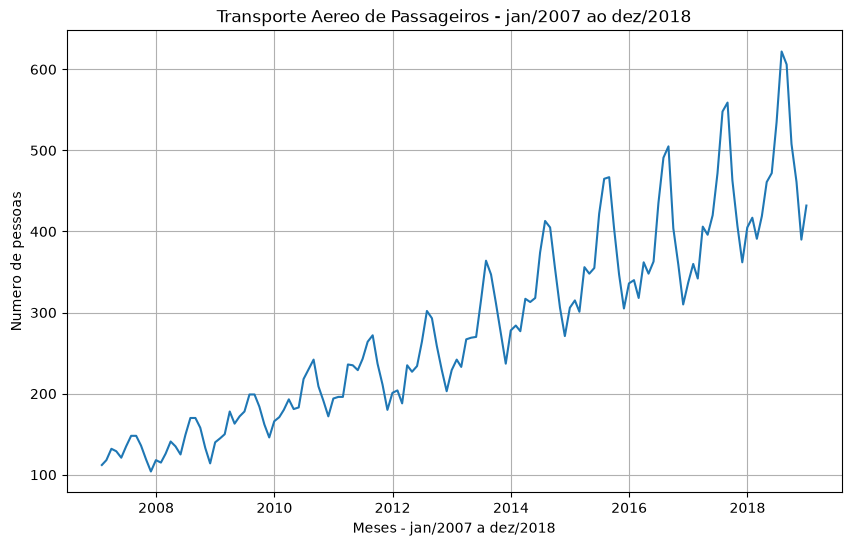

In [20]:
# Plotando o grafico

plt.figure(figsize=(10, 6))
plt.plot(airpas)
plt.title("Transporte Aereo de Passageiros - jan/2007 ao dez/2018")
plt.xlabel("Meses - jan/2007 a dez/2018")
plt.ylabel("Numero de pessoas")
plt.grid(True)
plt.show()


In [21]:
# Definir os parametros de sazonalidade e numero de passos a  frente

season_length = 12  # Por exemplo, 12 meses para sazonalidade anual
steps_ahead = 12  # Prevendo os proximos 12 peri­odos (um ano a  frente - h)


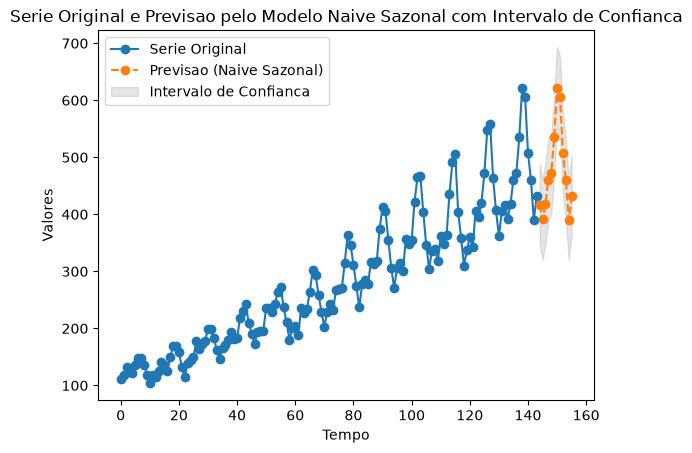

In [22]:
# Gerar previsao e intervalos de confianca pelo modelo Naive Sazonal

forecast, lower_bound, upper_bound = seasonal_naive_forecast(airpas, 
                                                season_length, steps_ahead)

forecast
lower_bound
upper_bound

# Chamar a funcao de plotagem
plot_seasonal_naive_forecast(airpas, forecast, lower_bound, upper_bound, 
                             steps_ahead)


In [23]:
# Placeholder de encerramento da seção


###############################################################################
### Modelos de SUAVIZACAO EXPONENCIAL - Simples
###############################################################################


## Preparação para Modelos de Suavização Exponencial

Até o momento vimos métodos **ingênuos** (Naive, Média, Drift) que servem como baseline. Agora vamos avançar para métodos mais elaborados.

A **Suavização Exponencial** é uma família de modelos de previsão que atribui pesos decrescentes aos dados mais antigos. Diferente dos métodos simples, ela se adapta melhor a mudanças estruturais na série.

### Tipos de Suavização Exponencial (Holt-Winters)

1. **Simples (Simple Exponential Smoothing):** para séries sem tendência e sem sazonalidade.
2. **Holt ( Double Exponential Smoothing):** adiciona componente de tendência.
3. **Holt-Winters (Triple Exponential Smoothing):** adiciona componente sazonal.

### Conceito Central

A ideia é que observações mais recentes devem ter maior peso na previsão. O parâmetro de suavização $\alpha$ (entre 0 e 1) controla essa intensidade:

- $\alpha$ próximo de 1: pouca suavização, modelo reativo.
- $\alpha$ próximo de 0: muita suavização, modelo lento para reagir.

**Fórmula da previsão:**
$\hat{y}_{t+1} = \alpha y_t + (1 - \alpha) \hat{y}_t$

Na próxima seção, exploraremos a **Suavização Exponencial Simples** e suas variações.

---
### Referências Conceituais

- Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice*. OTexts.
- Makridakis, S., Wheelwright, S. C., & Hyndman, R. J. (1998). *Forecasting Methods and Applications*. Wiley.
- https://otexts.com/fpp2/
